# Sprint 4b — Advanced Refined: SHAP Stability Experiment
## N=30 Seeds · n_estimators=5,000 · Full 2×2 Mitigation Matrix

**Author:** Karol Duda  
**Project:** *Measuring and Controlling SHAP Explanation Instability in High-Stakes AML Systems*  
**University:** Tilburg University — MSc Data Science & Society  
**Dataset:** IEEE-CIS Fraud Detection (Kaggle, 590,540 transactions)

---

### What Changed vs. Sprint 4 Original

| Parameter | Original | Refined | Rationale |
|---|---|---|---|
| `SEEDS` | 0–9 (N=10) | 0–29 (N=30) | 45 → 435 pairwise comparisons; publication-grade statistical power |
| `n_estimators` | 3,000 | 5,000 | Reference model hit 2,996/3,000 — convergence still incomplete |
| `early_stopping_rounds` | 150 | 200 | Proportional to increased estimator budget |
| Artefact prefix | `s4_` | `s4r_` | Keeps original run intact on Google Drive |
| RQ3b | — | ✓ | SPW + Ensemble mitigation (completes full 2×2 matrix) |

Architecture, splits, SHAP subsample, and all metrics are **identical** to Sprint 4 original.  
Results are directly comparable — only seed sample size, convergence budget, and the RQ3b extension change.

---

> **Resuming on Colab?**  
> Run **Cell 1 (Setup)** → **Cell 2 (Master Reload)** → skip to any analysis cell you need.  
> The Master Reload cell detects which artefacts are already on Drive and populates all  
> in-memory variables automatically, so no retraining is required after a kernel restart.

## Cell 1 — Setup & Imports

In [1]:
# ============================================================
# SPRINT 4b REFINED — SETUP & IMPORTS
# N=30 seeds, n_estimators=5000
# Run this cell first on every Colab session.
# ============================================================
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shap
import xgboost as xgb
from itertools import combinations
from scipy.stats import spearmanr, ttest_rel
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score

from google.colab import drive
drive.mount('/content/drive')

PATH      = '/content/drive/MyDrive/'
SEEDS     = list(range(30))   # seeds 0–29  →  C(30,2) = 435 pairs
K_VALS    = [5, 10, 20]
SPW       = 27.46             # scale_pos_weight = n_neg / n_pos = 427342/15563
N_EST     = 5000              # convergence fix: original hit 2996/3000
ES_ROUNDS = 200               # early stopping patience (proportional to N_EST)
PREFIX    = 's4r_'            # artefact prefix — keeps original s4_ intact

plt.style.use('ggplot')
sns.set_palette("muted")

print(f"XGBoost : {xgb.__version__}")
print(f"SHAP    : {shap.__version__}")
print(f"N seeds : {len(SEEDS)}  →  {len(list(combinations(SEEDS,2)))} pairwise comparisons")
print("Environment ready. ✓")

Mounted at /content/drive
XGBoost : 3.2.0
SHAP    : 0.51.0
N seeds : 30  →  435 pairwise comparisons
Environment ready. ✓


## Cell 2 — Master Reload (Skip Training After Kernel Restart)

**Run this cell immediately after Setup** if artefacts are already saved to Google Drive.  
It populates all in-memory variables needed for analysis cells — no retraining required.

In [2]:
# ============================================================
# MASTER RELOAD — load all saved artefacts from Google Drive
# Safe to run even on a fresh run (skips missing files gracefully).
# After this cell, all analysis cells (RQ1–RQ3b, Section 10) work
# without re-running any training.
# ============================================================
_reloaded = []

# --- Condition A rankings ---
rankings_A = {}
ckpt_A = f'{PATH}{PREFIX}ckpt_A.json'
if os.path.exists(ckpt_A):
    with open(ckpt_A) as f:
        pr_aucs_A = {int(k): v for k, v in json.load(f).items()}
    for seed in list(pr_aucs_A.keys()):
        df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_A_seed{seed}.csv',
                           index_col=0, header=0)
        df_r.columns = ['mean_abs_shap']
        rankings_A[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
    _reloaded.append(f'rankings_A ({len(rankings_A)} seeds)')
else:
    pr_aucs_A = {}

# --- Condition B rankings ---
rankings_B = {}
ckpt_B = f'{PATH}{PREFIX}ckpt_B.json'
if os.path.exists(ckpt_B):
    with open(ckpt_B) as f:
        pr_aucs_B = {int(k): v for k, v in json.load(f).items()}
    for seed in list(pr_aucs_B.keys()):
        df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_B_seed{seed}.csv',
                           index_col=0, header=0)
        df_r.columns = ['mean_abs_shap']
        rankings_B[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
    _reloaded.append(f'rankings_B ({len(rankings_B)} seeds)')
else:
    pr_aucs_B = {}

# --- Stability CSVs ---
stab_A_path = f'{PATH}{PREFIX}stability_A.csv'
if os.path.exists(stab_A_path):
    stability_A = pd.read_csv(stab_A_path)
    _reloaded.append('stability_A')

stab_B_path = f'{PATH}{PREFIX}stability_B.csv'
if os.path.exists(stab_B_path):
    stability_B = pd.read_csv(stab_B_path)
    _reloaded.append('stability_B')

# --- RQ2 comparison table ---
rq2_path = f'{PATH}{PREFIX}rq2_comparison.csv'
if os.path.exists(rq2_path):
    df_rq2 = pd.read_csv(rq2_path)
    rq2_rows = df_rq2.to_dict('records')
    _reloaded.append('rq2_rows')

# --- Ensemble A ---
ens_path = f'{PATH}{PREFIX}rq3_ensemble.csv'
if os.path.exists(ens_path):
    df_ens = pd.read_csv(ens_path)
    _reloaded.append('df_ens')

ens_ranking_path = f'{PATH}{PREFIX}shap_ranking_ensemble.csv'
if os.path.exists(ens_ranking_path):
    _df = pd.read_csv(ens_ranking_path, index_col=0, header=0)
    _df.columns = ['mean_abs_shap']
    ensemble_ranking = _df['mean_abs_shap'].sort_values(ascending=False)
    _reloaded.append('ensemble_ranking')

# --- Ensemble B (RQ3b) ---
ens_B_path = f'{PATH}{PREFIX}rq3b_ensemble_B.csv'
if os.path.exists(ens_B_path):
    df_ens_B = pd.read_csv(ens_B_path)
    _reloaded.append('df_ens_B')

ens_B_ranking_path = f'{PATH}{PREFIX}shap_ranking_ensemble_B.csv'
if os.path.exists(ens_B_ranking_path):
    _df = pd.read_csv(ens_B_ranking_path, index_col=0, header=0)
    _df.columns = ['mean_abs_shap']
    ensemble_ranking_B = _df['mean_abs_shap'].sort_values(ascending=False)
    _reloaded.append('ensemble_ranking_B')

# --- Reference ranking ---
ref_ranking_path = f'{PATH}{PREFIX}shap_ranking_ref.csv'
if os.path.exists(ref_ranking_path):
    _df = pd.read_csv(ref_ranking_path, index_col=0, header=0)
    _df.columns = ['mean_abs_shap']
    ref_ranking = _df['mean_abs_shap'].sort_values(ascending=False)
    _reloaded.append('ref_ranking')

# --- k-fold results ---
kfold_path = f'{PATH}{PREFIX}kfold_results.csv'
if os.path.exists(kfold_path):
    df_kfold = pd.read_csv(kfold_path)
    mean_pr  = df_kfold['PR_AUC'].mean()
    std_pr   = df_kfold['PR_AUC'].std()
    _reloaded.append('df_kfold')

print("=" * 55)
print("  MASTER RELOAD — STATUS")
print("=" * 55)
if _reloaded:
    for item in _reloaded:
        print(f"  ✓  {item}")
    print(f"\n  {len(_reloaded)} artefact(s) loaded from Google Drive.")
    print("  You can skip directly to any analysis cell.")
else:
    print("  No artefacts found. Run cells 3–9 (training) first.")
print("=" * 55)

  MASTER RELOAD — STATUS
  ✓  rankings_A (30 seeds)
  ✓  rankings_B (30 seeds)
  ✓  stability_A
  ✓  stability_B
  ✓  rq2_rows
  ✓  df_ens
  ✓  ensemble_ranking
  ✓  df_ens_B
  ✓  ensemble_ranking_B
  ✓  ref_ranking
  ✓  df_kfold

  11 artefact(s) loaded from Google Drive.
  You can skip directly to any analysis cell.


## 1. Data Loading & 4-Way Temporal Split

In [3]:
# ============================================================
# LOAD FROZEN ARTIFACT
# Identical to original Sprint 4 — reproduced for self-contained execution.
# ============================================================
print("Loading frozen dataset artifact...")
train = pd.read_parquet(f'{PATH}train_processed.parquet')

for col in train.columns:
    if train[col].dtype.name == 'category' or train[col].dtype == 'object':
        train[col] = pd.factorize(train[col])[0].astype('int16')

train.sort_values('TransactionDT', inplace=True)
train.reset_index(drop=True, inplace=True)
y = train['isFraud'].copy()

cols_adv = [c for c in train.columns if c not in ['isFraud', 'TransactionDT']]

n = len(train)
i_train_end = int(n * 0.65)
i_val_end   = int(n * 0.80)
i_test_end  = int(n * 0.92)

idxT  = train.index[:i_train_end]
idxV  = train.index[i_train_end:i_val_end]
idxTE = train.index[i_val_end:i_test_end]
idxSH = train.index[i_test_end:]

print(f"\n{'='*50}")
print(f"  4-WAY SPLIT SUMMARY")
print(f"{'='*50}")
for name, idx in [('TRAIN', idxT), ('VAL', idxV),
                   ('TEST', idxTE), ('SHAP', idxSH)]:
    fraud_r = y.loc[idx].mean()
    print(f"  {name:<6}: {len(idx):>7,} rows | fraud rate = {fraud_r:.3%}")
print(f"  TOTAL : {n:>7,} rows")
print(f"\n  Features: {len(cols_adv)}")

Loading frozen dataset artifact...

  4-WAY SPLIT SUMMARY
  TRAIN : 383,851 rows | fraud rate = 3.420%
  VAL   :  88,581 rows | fraud rate = 3.921%
  TEST  :  70,864 rows | fraud rate = 3.161%
  SHAP  :  47,244 rows | fraud rate = 3.861%
  TOTAL : 590,540 rows

  Features: 440


## 2. Universal Evaluation Function

In [4]:
from sklearn.metrics import (precision_recall_curve, roc_curve,
                              confusion_matrix, f1_score,
                              precision_score, recall_score)

def evaluate_model(model_name, y_true, y_pred_proba, color='steelblue',
                   ax_pr=None, ax_roc=None, verbose=True):
    pr_auc  = average_precision_score(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_vals  = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_vals[:-1])
    best_thr = thresholds[best_idx]

    y_pred = (y_pred_proba >= best_thr).astype(int)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred,    zero_division=0)
    f1   = f1_score(y_true, y_pred,        zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    if verbose:
        print(f"\n{'='*55}")
        print(f"  MODEL: {model_name}")
        print(f"{'='*55}")
        print(f"  PR-AUC (TEST)    : {pr_auc:.4f}   ← primary metric")
        print(f"  ROC-AUC (TEST)   : {roc_auc:.4f}   ← for comparison only")
        print(f"  Threshold F1-opt : {best_thr:.4f}")
        print(f"  Precision        : {prec:.4f}")
        print(f"  Recall           : {rec:.4f}")
        print(f"  F1-Score         : {f1:.4f}")
        print(f"\n  Confusion Matrix (TEST set):")
        print(f"  TN={cm[0,0]:>6,}  FP={cm[0,1]:>5,}")
        print(f"  FN={cm[1,0]:>6,}  TP={cm[1,1]:>5,}")

    if ax_pr is not None:
        ax_pr.plot(recalls, precisions,
                   label=f'{model_name} (PR={pr_auc:.3f})',
                   color=color, linewidth=2)
    if ax_roc is not None:
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        ax_roc.plot(fpr, tpr,
                    label=f'{model_name} (ROC={roc_auc:.3f})',
                    color=color, linewidth=2)

    return dict(Model=model_name, PR_AUC=round(pr_auc,4),
                ROC_AUC=round(roc_auc,4), Threshold=round(best_thr,4),
                Precision=round(prec,4), Recall=round(rec,4), F1=round(f1,4),
                TN=cm[0,0], FP=cm[0,1], FN=cm[1,0], TP=cm[1,1])

results_s4r = []
print("Evaluation framework loaded. ✓")

Evaluation framework loaded. ✓


## 3. Section A — TimeSeriesSplit: Predictive Robustness Check

In [5]:
# ============================================================
# TIMESERIESSPLIT — 5 FOLDS ON TRAIN+VAL (first 80%)
# n_estimators=5000 for consistency with seed experiments
# Runtime: ~20–30 min on Colab A100
# ============================================================
# Checkpoint: results saved to s4r_kfold_results.csv — skip if exists
kfold_done = os.path.exists(f'{PATH}{PREFIX}kfold_results.csv')
if kfold_done:
    df_kfold = pd.read_csv(f'{PATH}{PREFIX}kfold_results.csv')
    mean_pr  = df_kfold['PR_AUC'].mean()
    std_pr   = df_kfold['PR_AUC'].std()
    mean_roc = df_kfold['ROC_AUC'].mean()
    std_roc  = df_kfold['ROC_AUC'].std()
    print("Loaded k-fold results from Drive. ✓")
    print(df_kfold[['Fold','PR_AUC','ROC_AUC','Best_iteration']].to_string(index=False))
    print(f"\n  PR-AUC  : mean={mean_pr:.4f} ± std={std_pr:.4f}")
    print(f"  ROC-AUC : mean={mean_roc:.4f} ± std={std_roc:.4f}")
else:
    print("=== Section A: TimeSeriesSplit Performance Robustness ===\n")

    X_kfold = train.iloc[:i_val_end][cols_adv]
    y_kfold = y.iloc[:i_val_end]

    tscv = TimeSeriesSplit(n_splits=5)
    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_kfold)):
        X_tr  = X_kfold.iloc[tr_idx];  y_tr  = y_kfold.iloc[tr_idx]
        X_val = X_kfold.iloc[val_idx]; y_val = y_kfold.iloc[val_idx]

        clf_fold = xgb.XGBClassifier(
            n_estimators=N_EST, max_depth=12, learning_rate=0.02,
            subsample=0.8, colsample_bytree=0.4, missing=-1,
            eval_metric='aucpr', early_stopping_rounds=ES_ROUNDS,
            tree_method='hist', device='cuda', random_state=42
        )
        clf_fold.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds_fold = clf_fold.predict_proba(X_val)[:, 1]
        pr  = average_precision_score(y_val, preds_fold)
        roc = roc_auc_score(y_val, preds_fold)
        n_trees = clf_fold.best_iteration
        fold_results.append({'Fold': fold+1, 'Train_rows': len(tr_idx),
                              'Val_rows': len(val_idx), 'PR_AUC': round(pr, 4),
                              'ROC_AUC': round(roc, 4), 'Best_iteration': n_trees})
        print(f"  Fold {fold+1}: PR-AUC={pr:.4f} | ROC={roc:.4f} | trees={n_trees}")
        del clf_fold; gc.collect()

    df_kfold = pd.DataFrame(fold_results)
    df_kfold.to_csv(f'{PATH}{PREFIX}kfold_results.csv', index=False)
    mean_pr  = df_kfold['PR_AUC'].mean();  std_pr  = df_kfold['PR_AUC'].std()
    mean_roc = df_kfold['ROC_AUC'].mean(); std_roc = df_kfold['ROC_AUC'].std()
    print(f"\n  PR-AUC  : mean={mean_pr:.4f} ± std={std_pr:.4f}")
    print(f"  ROC-AUC : mean={mean_roc:.4f} ± std={std_roc:.4f}")
    print(f"  Original (n_est=3000): mean=0.6715 ± 0.0346")

Loaded k-fold results from Drive. ✓
 Fold  PR_AUC  ROC_AUC  Best_iteration
    1  0.6261   0.9090            3219
    2  0.6752   0.9169            1960
    3  0.7104   0.9365            3188
    4  0.6569   0.9287            3003
    5  0.7143   0.9501            4952

  PR-AUC  : mean=0.6766 ± std=0.0371
  ROC-AUC : mean=0.9282 ± std=0.0162


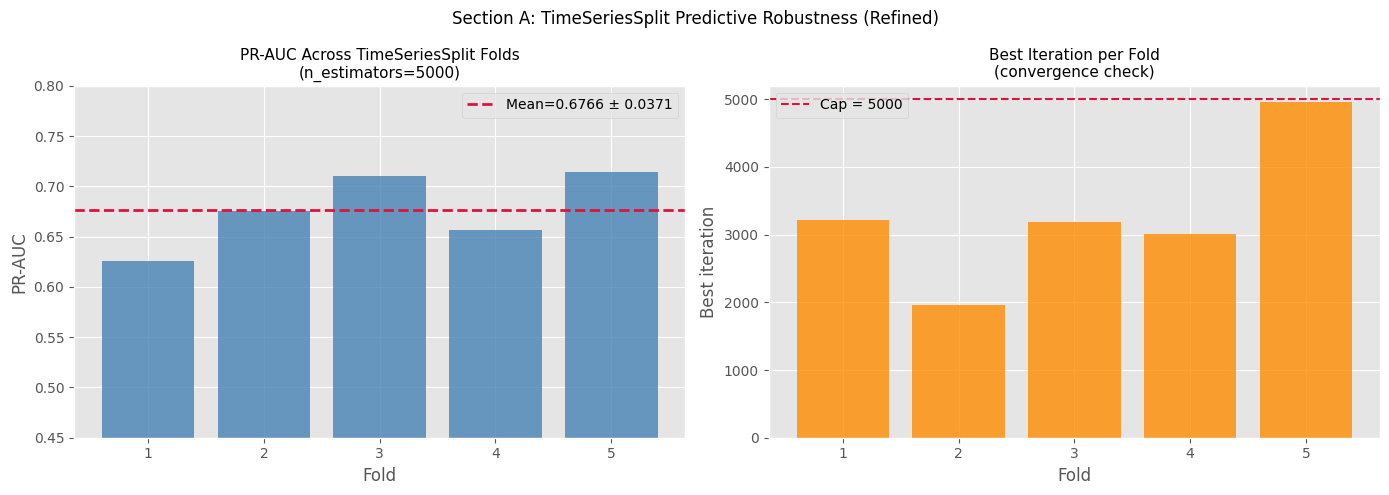

In [6]:
# K-FOLD VISUALISATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
folds = df_kfold['Fold'].values

ax1.bar(folds, df_kfold['PR_AUC'], color='steelblue', alpha=0.8)
ax1.axhline(mean_pr, color='crimson', linestyle='--', linewidth=2,
            label=f'Mean={mean_pr:.4f} ± {std_pr:.4f}')
ax1.set_title('PR-AUC Across TimeSeriesSplit Folds\n(n_estimators=5000)', fontsize=11)
ax1.set_xlabel('Fold'); ax1.set_ylabel('PR-AUC')
ax1.set_ylim([0.45, 0.80]); ax1.legend()

ax2.bar(folds, df_kfold['Best_iteration'], color='darkorange', alpha=0.8)
ax2.axhline(N_EST, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Cap = {N_EST}')
ax2.set_title('Best Iteration per Fold\n(convergence check)', fontsize=11)
ax2.set_xlabel('Fold'); ax2.set_ylabel('Best iteration')
ax2.legend()

plt.suptitle('Section A: TimeSeriesSplit Predictive Robustness (Refined)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PATH}{PREFIX}kfold.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Section B — Reference Model (seed=42, n_estimators=5,000)

In [7]:
# ============================================================
# REFERENCE MODEL: seed=42, n_estimators=5000
# Checkpoint: loads predictions from Drive if already trained.
# ============================================================
ref_pred_path = f'{PATH}{PREFIX}preds_ref_test.npy'
if os.path.exists(ref_pred_path):
    preds_ref_test = np.load(ref_pred_path)
    res_ref = evaluate_model('XGBoost ref (seed=42, n_est=5000)',
                              y.loc[idxTE], preds_ref_test, color='crimson')
    results_s4r.append(res_ref)
    print("\nLoaded reference model predictions from Drive. ✓")
else:
    print("=== Section B: Reference Model (seed=42, n_estimators=5000) ===\n")
    clf_ref = xgb.XGBClassifier(
        n_estimators=N_EST, max_depth=12, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.4, missing=-1,
        eval_metric='aucpr', early_stopping_rounds=ES_ROUNDS,
        tree_method='hist', device='cuda', random_state=42
    )
    clf_ref.fit(
        train.loc[idxT, cols_adv], y.loc[idxT],
        eval_set=[(train.loc[idxV, cols_adv], y.loc[idxV])],
        verbose=500
    )
    print(f"\n  Best iteration : {clf_ref.best_iteration} / {N_EST}")
    converged = clf_ref.best_iteration < (N_EST - ES_ROUNDS - 50)
    print(f"  Converged      : {'YES ✓' if converged else 'NO — increase N_EST further'}")

    preds_ref_test = clf_ref.predict_proba(train.loc[idxTE, cols_adv])[:, 1]
    res_ref = evaluate_model('XGBoost ref (seed=42, n_est=5000)',
                              y.loc[idxTE], preds_ref_test, color='crimson')
    results_s4r.append(res_ref)
    np.save(ref_pred_path, preds_ref_test)


  MODEL: XGBoost ref (seed=42, n_est=5000)
  PR-AUC (TEST)    : 0.5636   ← primary metric
  ROC-AUC (TEST)   : 0.9166   ← for comparison only
  Threshold F1-opt : 0.1395
  Precision        : 0.6827
  Recall           : 0.4696
  F1-Score         : 0.5565

  Confusion Matrix (TEST set):
  TN=68,135  FP=  489
  FN= 1,188  TP=1,052

Loaded reference model predictions from Drive. ✓


## 5. Section B (cont.) — SHAP Foundation on SHAP Set

In [8]:
# ============================================================
# STRATIFIED SHAP SUBSAMPLE — identical to original Sprint 4
# Fixed subsample ensures comparability across runs.
# ============================================================
shap_idx_path = f'{PATH}{PREFIX}shap_sample_idx.npy'
if os.path.exists(shap_idx_path):
    sample_idx = pd.Index(np.load(shap_idx_path))
else:
    np.random.seed(42)
    fraud_rate_shap = y.loc[idxSH].mean()
    val_fraud = train.loc[idxSH][y.loc[idxSH] == 1]
    val_legit  = train.loc[idxSH][y.loc[idxSH] == 0]
    n_fraud = int(10_000 * fraud_rate_shap)
    n_legit = 10_000 - n_fraud
    sample_idx = pd.concat([
        val_fraud.sample(n=n_fraud, random_state=42),
        val_legit.sample(n=n_legit, random_state=42)
    ]).index
    np.save(shap_idx_path, sample_idx.values)

X_shap = train.loc[sample_idx, cols_adv]
y_shap = y.loc[sample_idx]
print(f"SHAP subsample: {len(X_shap):,} obs | fraud={y_shap.sum()} ({y_shap.mean():.2%})")

# Load or compute reference SHAP ranking
ref_rank_path = f'{PATH}{PREFIX}shap_ranking_ref.csv'
if os.path.exists(ref_rank_path):
    _df = pd.read_csv(ref_rank_path, index_col=0, header=0)
    _df.columns = ['mean_abs_shap']
    ref_ranking = _df['mean_abs_shap'].sort_values(ascending=False)
    print("Loaded reference SHAP ranking from Drive. ✓")
else:
    # Need clf_ref in memory — run Section B training cell first
    print("Computing TreeSHAP for reference model (seed=42)...")
    explainer_ref = shap.TreeExplainer(clf_ref)
    shap_vals_ref = explainer_ref.shap_values(X_shap)
    ref_ranking = pd.Series(
        np.abs(shap_vals_ref).mean(axis=0), index=cols_adv
    ).sort_values(ascending=False)
    ref_ranking.to_csv(ref_rank_path, header=['mean_abs_shap'])
    np.save(f'{PATH}{PREFIX}shap_values_ref.npy', shap_vals_ref)
    del explainer_ref, shap_vals_ref; gc.collect()

print("\n=== TOP-20 SHAP FEATURES — Reference (seed=42, n_est=5000) ===")
print(ref_ranking.head(20).to_string())

SHAP subsample: 10,000 obs | fraud=386 (3.86%)
Loaded reference SHAP ranking from Drive. ✓

=== TOP-20 SHAP FEATURES — Reference (seed=42, n_est=5000) ===
C13                        0.520023
TransactionAmt_uid_mean    0.344059
card1_FE                   0.274293
TransactionAmt_uid_std     0.272318
TransactionAmt             0.264820
D11_uid_mean               0.262120
C1                         0.259872
card1                      0.255438
D11                        0.245240
card6                      0.242054
D11_uid_std                0.237689
card2                      0.235839
addr1_FE                   0.225757
D4                         0.225566
addr1                      0.191817
C14                        0.191464
D15                        0.184038
D10                        0.175043
M5                         0.169662
C11                        0.159310


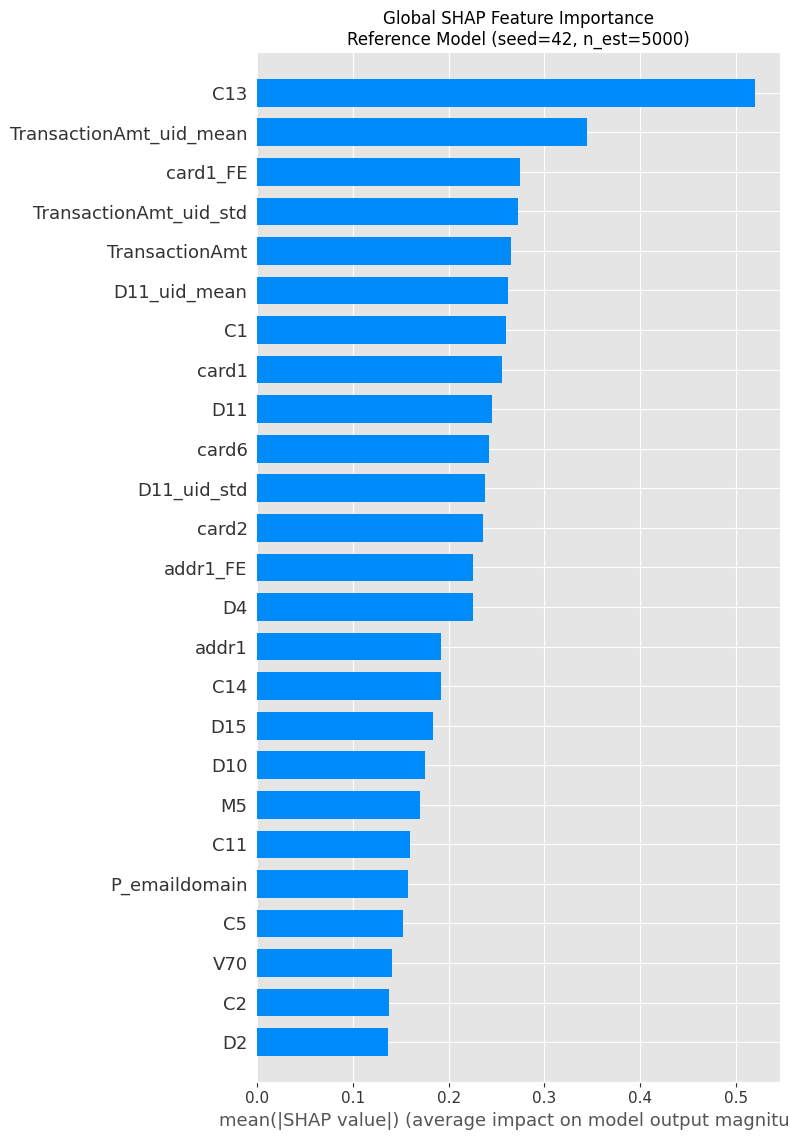

In [9]:
# SHAP SUMMARY PLOT — Reference model
# Note: requires shap_vals_ref in memory OR shap_values_ref.npy on Drive
shap_npy_path = f'{PATH}{PREFIX}shap_values_ref.npy'
if os.path.exists(shap_npy_path):
    shap_vals_ref = np.load(shap_npy_path)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals_ref, X_shap, max_display=25,
                      show=False, plot_type='bar')
    plt.title('Global SHAP Feature Importance\nReference Model (seed=42, n_est=5000)',
              fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{PATH}{PREFIX}shap_reference.png', dpi=150, bbox_inches='tight')
    plt.show()
    del shap_vals_ref; gc.collect()
else:
    print("shap_values_ref.npy not found on Drive — run SHAP Foundation cell first.")

## 6. Stability Utility Functions

In [10]:
# ============================================================
# STABILITY UTILITY FUNCTIONS — identical to original Sprint 4
# ============================================================

def jaccard(set_a, set_b):
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


def compute_stability(rankings_dict, k_values=K_VALS):
    """Compute all C(N,2) pairwise Jaccard + Spearman metrics."""
    labels = list(rankings_dict.keys())
    rows = []
    for l1, l2 in combinations(labels, 2):
        r1, r2 = rankings_dict[l1], rankings_dict[l2]
        common = r1.index.intersection(r2.index)
        rho, _ = spearmanr(
            r1[common].rank(ascending=False, method='average'),
            r2[common].rank(ascending=False, method='average')
        )
        row = {'label_1': l1, 'label_2': l2, 'spearman_rho': round(rho, 4)}
        for k in k_values:
            row[f'jaccard_k{k}'] = round(
                jaccard(set(r1.head(k).index), set(r2.head(k).index)), 4)
        rows.append(row)
    return pd.DataFrame(rows)


def summarise_stability(df_stab, label=''):
    metrics = ['spearman_rho'] + [f'jaccard_k{k}' for k in K_VALS]
    summary = df_stab[metrics].agg(['mean','std','min','max']).round(4)
    print(f"\n=== Stability Summary: {label} ===")
    print(summary.to_string())
    return summary


def train_and_explain(seed, scale_pos_weight=None, n_estimators=None):
    """Train one XGBoost model and return (PR-AUC, SHAP ranking).

    Parameters
    ----------
    seed : int
        Random seed for XGBoost.
    scale_pos_weight : float or None
        Class weight for positive class (SPW). None = unweighted.
    n_estimators : int or None
        Number of trees. Defaults to N_EST global.
    """
    if n_estimators is None:
        n_estimators = N_EST
    tag = f"SPW={scale_pos_weight:.1f}" if scale_pos_weight else "unweighted"
    print(f"  Seed {seed:2d} | {tag} ...", end=' ')

    params = dict(n_estimators=n_estimators, max_depth=12,
                  learning_rate=0.02, subsample=0.8,
                  colsample_bytree=0.4, missing=-1,
                  eval_metric='aucpr', early_stopping_rounds=ES_ROUNDS,
                  tree_method='hist', device='cuda', random_state=seed)
    if scale_pos_weight:
        params['scale_pos_weight'] = scale_pos_weight

    clf = xgb.XGBClassifier(**params)
    clf.fit(train.loc[idxT, cols_adv], y.loc[idxT],
            eval_set=[(train.loc[idxV, cols_adv], y.loc[idxV])],
            verbose=False)

    preds_test = clf.predict_proba(train.loc[idxTE, cols_adv])[:, 1]
    pr_auc_test = average_precision_score(y.loc[idxTE], preds_test)

    exp = shap.TreeExplainer(clf)
    sv  = exp.shap_values(X_shap)
    ranking = pd.Series(
        np.abs(sv).mean(axis=0), index=cols_adv
    ).sort_values(ascending=False)

    print(f"PR-AUC(test)={pr_auc_test:.4f} | trees={clf.best_iteration}")

    del clf, exp, sv; gc.collect()
    return pr_auc_test, ranking


print(f"Utility functions loaded. ✓")
print(f"C({len(SEEDS)},2) = {len(list(combinations(SEEDS,2)))} pairwise comparisons per condition.")

Utility functions loaded. ✓
C(30,2) = 435 pairwise comparisons per condition.


## 7. RQ1 — Seed Perturbation Experiment (Condition A: Unweighted, N=30)

**Runtime: ~3–4 h on Colab A100.** Checkpoint-enabled — safe to interrupt and resume.  
Skip this cell entirely if `rankings_A` was already loaded by the Master Reload cell.

In [11]:
# ============================================================
# RQ1: TRAIN N=30 MODELS — CONDITION A (unweighted)
# Checkpoint after each seed — resumes automatically if interrupted.
# ============================================================
if len(rankings_A) == len(SEEDS):
    print(f"Condition A already complete ({len(rankings_A)} seeds). Skipping training. ✓")
else:
    print(f"=== RQ1: Condition A — Seed Perturbation (N=30) ===")
    print(f"Training {len(SEEDS)} models with seeds {SEEDS}...\n")

    ckpt_path = f'{PATH}{PREFIX}ckpt_A.json'
    if os.path.exists(ckpt_path):
        with open(ckpt_path) as f:
            pr_aucs_A = {int(k): v for k, v in json.load(f).items()}
        for seed in list(pr_aucs_A.keys()):
            if seed not in rankings_A:
                df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_A_seed{seed}.csv',
                                   index_col=0, header=0)
                df_r.columns = ['mean_abs_shap']
                rankings_A[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
        print(f"  Resumed: {len(pr_aucs_A)} seeds already done.")

    for seed in SEEDS:
        if seed in pr_aucs_A:
            continue
        pr, ranking = train_and_explain(seed, scale_pos_weight=None)
        rankings_A[seed] = ranking
        pr_aucs_A[seed]  = pr
        ranking.to_csv(f'{PATH}{PREFIX}ranking_A_seed{seed}.csv',
                       header=['mean_abs_shap'])
        with open(f'{PATH}{PREFIX}ckpt_A.json', 'w') as f:
            json.dump(pr_aucs_A, f)

vals = list(pr_aucs_A.values())
print(f"\n--- PR-AUC Summary (Condition A, N=30) ---")
print(f"  Range : {min(vals):.4f} – {max(vals):.4f}")
print(f"  Mean  : {np.mean(vals):.4f}")
print(f"  Std   : {np.std(vals):.4f}")
print(f"\n  Original N=10: mean=0.5585, std=0.0052")
print(f"  Outlier check — seed 26 (expected early stop ~1187 trees): "
      f"{pr_aucs_A.get(26, 'N/A')}")

Condition A already complete (30 seeds). Skipping training. ✓

--- PR-AUC Summary (Condition A, N=30) ---
  Range : 0.5482 – 0.5677
  Mean  : 0.5639
  Std   : 0.0036

  Original N=10: mean=0.5585, std=0.0052
  Outlier check — seed 26 (expected early stop ~1187 trees): 0.5481777795365314


In [12]:
# ============================================================
# RQ1: STABILITY METRICS — 435 PAIRWISE COMPARISONS
# ============================================================
stab_A_csv = f'{PATH}{PREFIX}stability_A.csv'
if 'stability_A' not in dir() or stability_A is None:
    if os.path.exists(stab_A_csv):
        stability_A = pd.read_csv(stab_A_csv)
        print("Loaded stability_A from Drive. ✓")
    else:
        stability_A = compute_stability(rankings_A)
        stability_A.to_csv(stab_A_csv, index=False)

summary_A = summarise_stability(stability_A, f'Condition A — Unweighted (N={len(SEEDS)})')

print(f"\n  Original N=10 (45 pairs):")
print(f"    Spearman ρ  : 0.9725 ± 0.0044")
print(f"    Jaccard k=5 : 0.6381 ± 0.1531")
print(f"    Jaccard k=10: 0.8350 ± 0.1043")
print(f"    Jaccard k=20: 0.8405 ± 0.0999")

# Each seed vs. reference
print(f"\n--- Each seed vs. Reference (seed=42, n_est=5000) ---")
ref_rows = []
for seed in SEEDS:
    common = rankings_A[seed].index.intersection(ref_ranking.index)
    rho, _ = spearmanr(
        rankings_A[seed][common].rank(ascending=False),
        ref_ranking[common].rank(ascending=False)
    )
    row = {'seed': seed, 'spearman_vs_ref': round(rho, 4)}
    for k in K_VALS:
        j = jaccard(set(rankings_A[seed].head(k).index),
                    set(ref_ranking.head(k).index))
        row[f'jaccard_k{k}_vs_ref'] = round(j, 4)
    ref_rows.append(row)
    print(f"  Seed {seed:2d}: ρ={rho:.4f} | "
          f"J@5={row['jaccard_k5_vs_ref']:.3f} | "
          f"J@10={row['jaccard_k10_vs_ref']:.3f} | "
          f"J@20={row['jaccard_k20_vs_ref']:.3f}")

pd.DataFrame(ref_rows).to_csv(f'{PATH}{PREFIX}stability_A_vs_ref.csv', index=False)


=== Stability Summary: Condition A — Unweighted (N=30) ===
      spearman_rho  jaccard_k5  jaccard_k10  jaccard_k20
mean        0.9774      0.6922       0.8334       0.9452
std         0.0043      0.1854       0.0951       0.0916
min         0.9601      0.2500       0.6667       0.6667
max         0.9846      1.0000       1.0000       1.0000

  Original N=10 (45 pairs):
    Spearman ρ  : 0.9725 ± 0.0044
    Jaccard k=5 : 0.6381 ± 0.1531
    Jaccard k=10: 0.8350 ± 0.1043
    Jaccard k=20: 0.8405 ± 0.0999

--- Each seed vs. Reference (seed=42, n_est=5000) ---
  Seed  0: ρ=0.9790 | J@5=0.667 | J@10=0.818 | J@20=0.905
  Seed  1: ρ=0.9864 | J@5=0.667 | J@10=0.818 | J@20=0.905
  Seed  2: ρ=0.9802 | J@5=0.667 | J@10=0.818 | J@20=0.905
  Seed  3: ρ=0.9789 | J@5=0.667 | J@10=1.000 | J@20=0.905
  Seed  4: ρ=0.9831 | J@5=1.000 | J@10=1.000 | J@20=1.000
  Seed  5: ρ=0.9804 | J@5=0.429 | J@10=0.818 | J@20=0.905
  Seed  6: ρ=0.9818 | J@5=0.429 | J@10=1.000 | J@20=0.905
  Seed  7: ρ=0.9815 | J@5=1.0

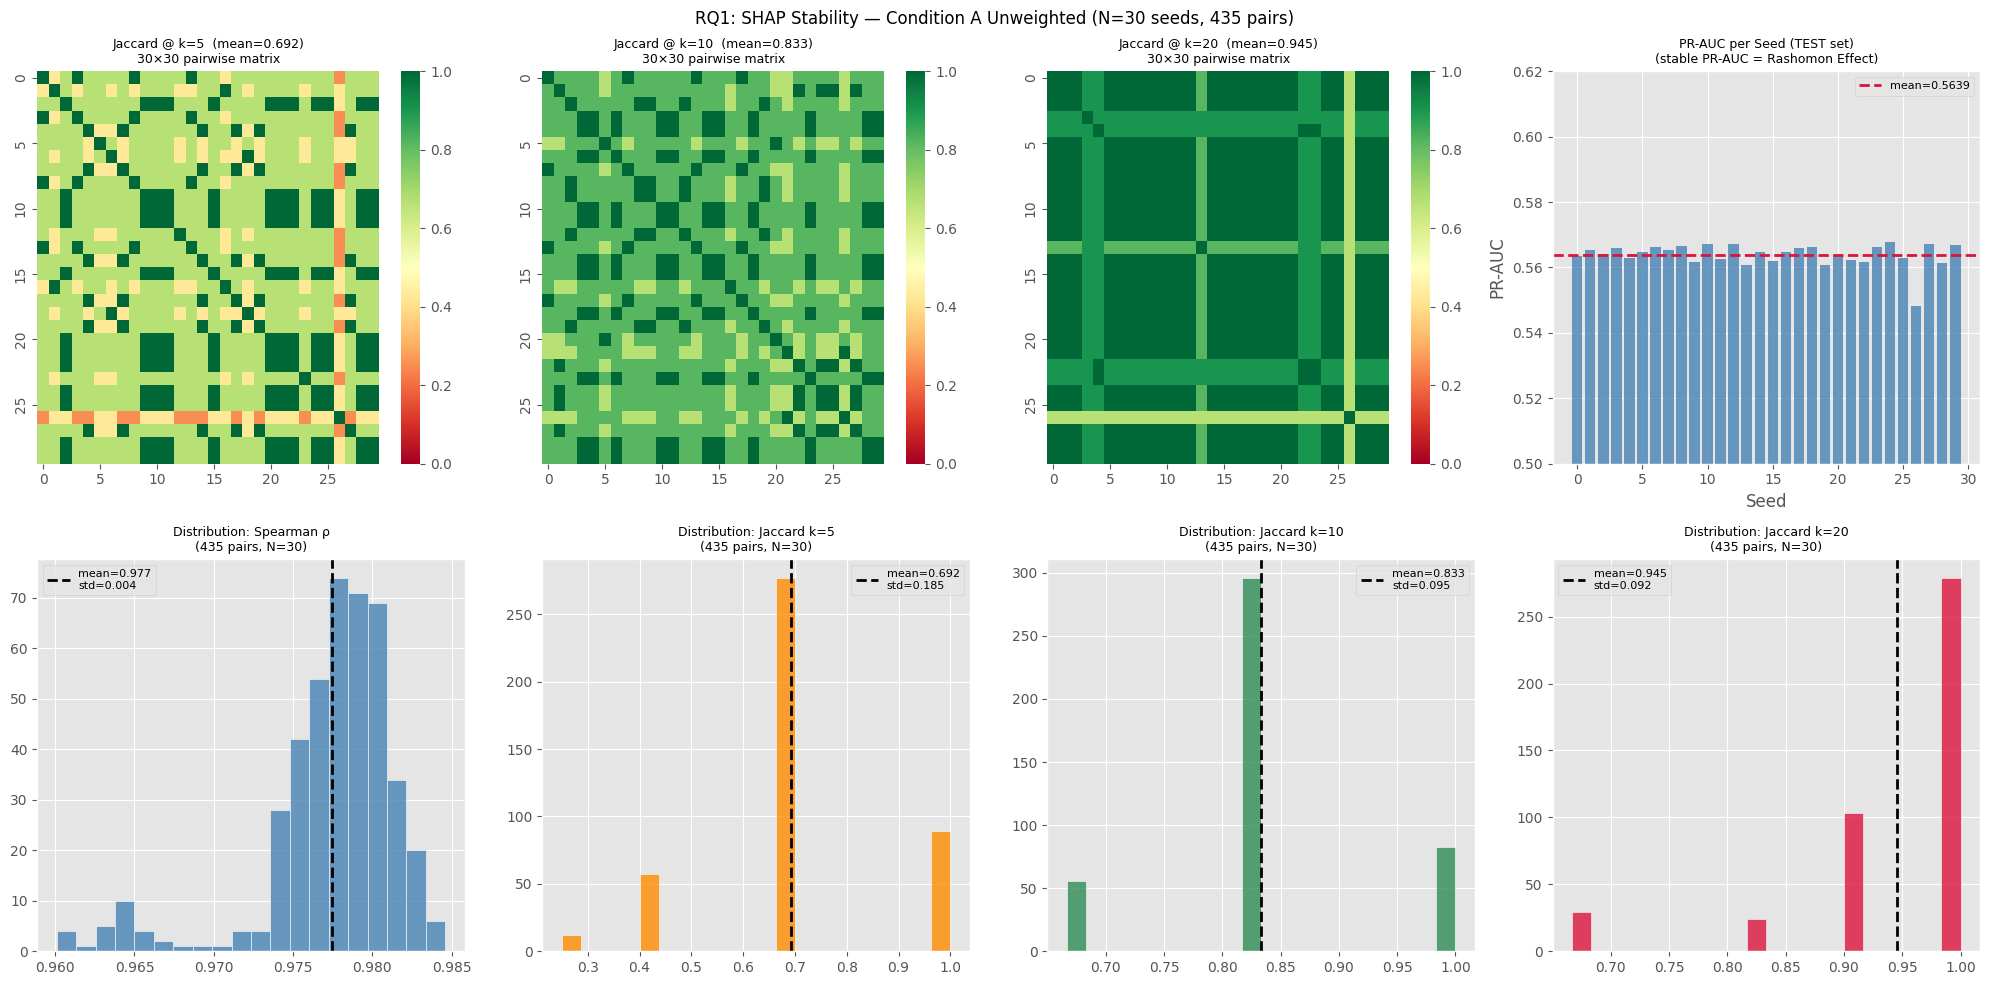

In [13]:
# ============================================================
# RQ1: VISUALISATIONS — 30x30 heatmaps + distributions
# ============================================================
fig = plt.figure(figsize=(20, 10))

# Row 1: Jaccard heatmaps (no annotations — 30×30 unreadable)
for i, k in enumerate(K_VALS):
    ax = fig.add_subplot(2, 4, i+1)
    col = f'jaccard_k{k}'
    mat = pd.DataFrame(np.eye(30), index=SEEDS, columns=SEEDS, dtype=float)
    for _, row in stability_A.iterrows():
        s1, s2 = int(row['label_1']), int(row['label_2'])
        mat.loc[s1, s2] = row[col]
        mat.loc[s2, s1] = row[col]
    sns.heatmap(mat, vmin=0, vmax=1, cmap='RdYlGn', ax=ax,
                xticklabels=5, yticklabels=5, cbar=True)
    mean_j = stability_A[col].mean()
    ax.set_title(f'Jaccard @ k={k}  (mean={mean_j:.3f})\n30×30 pairwise matrix', fontsize=9)

# Row 1, col 4: PR-AUC per seed
ax4 = fig.add_subplot(2, 4, 4)
vals = [pr_aucs_A[s] for s in SEEDS]
ax4.bar(SEEDS, vals, color='steelblue', alpha=0.8)
ax4.axhline(np.mean(vals), color='crimson', linestyle='--', linewidth=2,
            label=f"mean={np.mean(vals):.4f}")
ax4.set_title('PR-AUC per Seed (TEST set)\n(stable PR-AUC = Rashomon Effect)', fontsize=9)
ax4.set_xlabel('Seed'); ax4.set_ylabel('PR-AUC')
ax4.set_ylim([0.50, 0.62]); ax4.legend(fontsize=8)

# Row 2: Distributions
for i, (col, label, color) in enumerate([
    ('spearman_rho',  'Spearman ρ',   'steelblue'),
    ('jaccard_k5',    'Jaccard k=5',  'darkorange'),
    ('jaccard_k10',   'Jaccard k=10', 'seagreen'),
    ('jaccard_k20',   'Jaccard k=20', 'crimson'),
]):
    ax = fig.add_subplot(2, 4, 5+i)
    ax.hist(stability_A[col], bins=20, color=color, edgecolor='white', alpha=0.8)
    m = stability_A[col].mean()
    s = stability_A[col].std()
    ax.axvline(m, color='black', linestyle='--', linewidth=2,
               label=f'mean={m:.3f}\nstd={s:.3f}')
    ax.set_title(f'Distribution: {label}\n(435 pairs, N=30)', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle(f'RQ1: SHAP Stability — Condition A Unweighted (N={len(SEEDS)} seeds, 435 pairs)',
             fontsize=12)
plt.tight_layout()
plt.savefig(f'{PATH}{PREFIX}rq1_full.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. RQ2 — Class Imbalance Diagnostic (Condition B: Weighted, N=30)

**Runtime: ~3–4 h on Colab A100.** Checkpoint-enabled.  
Skip this cell if `rankings_B` was loaded by the Master Reload cell.

In [14]:
# ============================================================
# RQ2: TRAIN N=30 MODELS — CONDITION B (scale_pos_weight=27.46)
# Checkpoint-enabled — safe to interrupt and resume.
# ============================================================
if len(rankings_B) == len(SEEDS):
    print(f"Condition B already complete ({len(rankings_B)} seeds). Skipping training. ✓")
else:
    print(f"=== RQ2: Condition B — Weighted (SPW={SPW}, N={len(SEEDS)}) ===")
    print(f"Training {len(SEEDS)} models...\n")

    ckpt_path_B = f'{PATH}{PREFIX}ckpt_B.json'
    if os.path.exists(ckpt_path_B):
        with open(ckpt_path_B) as f:
            pr_aucs_B = {int(k): v for k, v in json.load(f).items()}
        for seed in list(pr_aucs_B.keys()):
            if seed not in rankings_B:
                df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_B_seed{seed}.csv',
                                   index_col=0, header=0)
                df_r.columns = ['mean_abs_shap']
                rankings_B[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
        print(f"  Resumed: {len(pr_aucs_B)} seeds already done.")

    for seed in SEEDS:
        if seed in pr_aucs_B:
            continue
        pr, ranking = train_and_explain(seed, scale_pos_weight=SPW)
        rankings_B[seed] = ranking
        pr_aucs_B[seed]  = pr
        ranking.to_csv(f'{PATH}{PREFIX}ranking_B_seed{seed}.csv',
                       header=['mean_abs_shap'])
        with open(f'{PATH}{PREFIX}ckpt_B.json', 'w') as f:
            json.dump(pr_aucs_B, f)

vals_B = list(pr_aucs_B.values())
print(f"\n--- PR-AUC Summary (Condition B, N=30) ---")
print(f"  Range : {min(vals_B):.4f} – {max(vals_B):.4f}")
print(f"  Mean  : {np.mean(vals_B):.4f}")
print(f"  Std   : {np.std(vals_B):.4f}")
print(f"\n  Original N=10: mean=0.5677, std=0.0012")

Condition B already complete (30 seeds). Skipping training. ✓

--- PR-AUC Summary (Condition B, N=30) ---
  Range : 0.5688 – 0.5763
  Mean  : 0.5727
  Std   : 0.0018

  Original N=10: mean=0.5677, std=0.0012


In [15]:
# ============================================================
# RQ2: STABILITY COMPARISON — 435 PAIRS EACH CONDITION
# ============================================================
stab_B_csv = f'{PATH}{PREFIX}stability_B.csv'
if 'stability_B' not in dir() or stability_B is None:
    if os.path.exists(stab_B_csv):
        stability_B = pd.read_csv(stab_B_csv)
        print("Loaded stability_B from Drive. ✓")
    else:
        stability_B = compute_stability(rankings_B)
        stability_B.to_csv(stab_B_csv, index=False)

summary_B = summarise_stability(stability_B, f'Condition B — Weighted (N={len(SEEDS)})')

print(f"\n=== RQ2: Direct Comparison A vs B (N={len(SEEDS)}, {len(stability_A)} pairs) ===")
metrics = ['spearman_rho'] + [f'jaccard_k{k}' for k in K_VALS]
rq2_rows = []
for metric in metrics:
    a_mean = stability_A[metric].mean()
    b_mean = stability_B[metric].mean()
    delta  = b_mean - a_mean
    _, pval = ttest_rel(stability_B[metric].values, stability_A[metric].values)
    sig = '*** (p<0.001)' if pval < 0.001 else '* (p<0.05)' if pval < 0.05 else '(n.s.)'
    direction = ('B more stable' if delta > 0.01 else
                 'A more stable' if delta < -0.01 else 'no difference')
    rq2_rows.append({'Metric': metric, 'A_mean': round(a_mean,4),
                     'B_mean': round(b_mean,4), 'Delta': round(delta,4),
                     'p_value': round(pval,6), 'Significance': sig, 'Result': direction})
    print(f"  {metric:<20}: A={a_mean:.4f} | B={b_mean:.4f} | "
          f"Δ={delta:+.4f}  {sig}  → {direction}")

pd.DataFrame(rq2_rows).to_csv(f'{PATH}{PREFIX}rq2_comparison.csv', index=False)


=== Stability Summary: Condition B — Weighted (N=30) ===
      spearman_rho  jaccard_k5  jaccard_k10  jaccard_k20
mean        0.9833      0.8651       0.9398       0.9147
std         0.0018      0.1638       0.0857       0.0582
min         0.9777      0.6667       0.8182       0.8182
max         0.9884      1.0000       1.0000       1.0000

=== RQ2: Direct Comparison A vs B (N=30, 435 pairs) ===
  spearman_rho        : A=0.9774 | B=0.9833 | Δ=+0.0059  *** (p<0.001)  → no difference
  jaccard_k5          : A=0.6922 | B=0.8651 | Δ=+0.1729  *** (p<0.001)  → B more stable
  jaccard_k10         : A=0.8334 | B=0.9398 | Δ=+0.1064  *** (p<0.001)  → B more stable
  jaccard_k20         : A=0.9452 | B=0.9147 | Δ=-0.0305  *** (p<0.001)  → A more stable


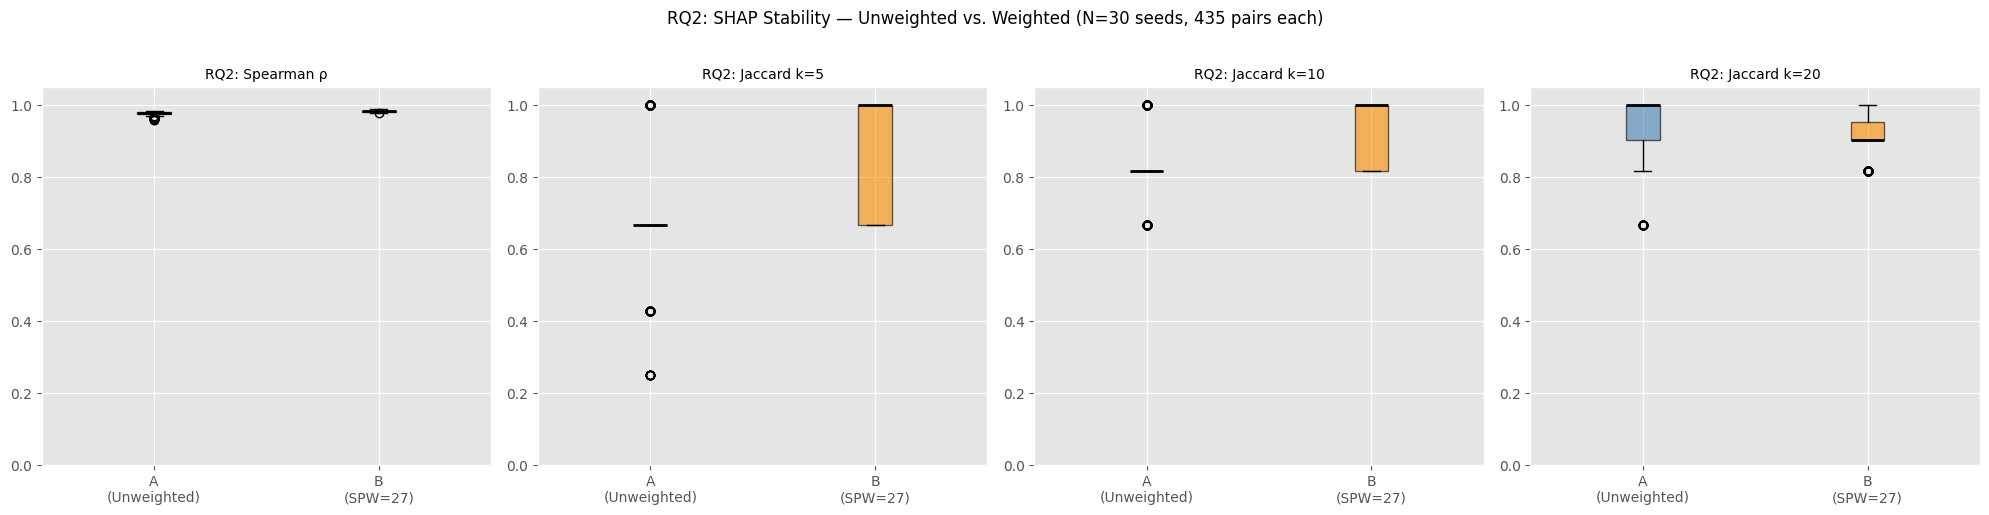

In [16]:
# RQ2 VISUALISATION
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric, title in zip(
    axes,
    ['spearman_rho', 'jaccard_k5', 'jaccard_k10', 'jaccard_k20'],
    ['Spearman ρ', 'Jaccard k=5', 'Jaccard k=10', 'Jaccard k=20']
):
    bp = ax.boxplot(
        [stability_A[metric].values, stability_B[metric].values],
        tick_labels=['A\n(Unweighted)', f'B\n(SPW={SPW:.0f})'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('steelblue');  bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('darkorange'); bp['boxes'][1].set_alpha(0.6)
    ax.set_title(f'RQ2: {title}', fontsize=10)
    ax.set_ylim([0, 1.05])

plt.suptitle(f'RQ2: SHAP Stability — Unweighted vs. Weighted '
             f'(N={len(SEEDS)} seeds, {len(stability_A)} pairs each)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{PATH}{PREFIX}rq2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. RQ3 + RQ3b — Ensemble Mitigation (Complete 2×2 Matrix)

**RQ3:** Ensemble over Condition A (unweighted).  
**RQ3b:** Ensemble over Condition B (SPW) — no retraining, uses saved CSVs.  
Together they complete the full 2×2 mitigation matrix: {weighting} × {ensembling}.

In [17]:
# ============================================================
# RQ3: BUILD ENSEMBLE EXPLANATION — CONDITION A
# Mean SHAP ranking over 30 unweighted models.
# ============================================================

# Defensive reload: ensure rankings_A is in memory
if not rankings_A:
    print("rankings_A not in memory — reloading from Drive...")
    for seed in SEEDS:
        df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_A_seed{seed}.csv',
                           index_col=0, header=0)
        df_r.columns = ['mean_abs_shap']
        rankings_A[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
    print(f"  Loaded {len(rankings_A)} seeds. ✓")

print(f"=== RQ3: Seed Ensemble Mitigation — Condition A (N={len(SEEDS)}) ===\n")

all_features = rankings_A[0].index
ensemble_ranking = pd.Series(
    np.mean([rankings_A[s].loc[all_features].values for s in SEEDS], axis=0),
    index=all_features
).sort_values(ascending=False)

ensemble_ranking.to_csv(f'{PATH}{PREFIX}shap_ranking_ensemble.csv',
                        header=['mean_abs_shap'])

print("=== TOP-20 ENSEMBLE A FEATURES (mean of 30 unweighted models) ===")
print(ensemble_ranking.head(20).to_string())
print()
for k in K_VALS:
    j = jaccard(set(ensemble_ranking.head(k).index), set(ref_ranking.head(k).index))
    print(f"  Ensemble A Top-{k} vs Reference (seed=42): Jaccard={j:.4f}")

=== RQ3: Seed Ensemble Mitigation — Condition A (N=30) ===

=== TOP-20 ENSEMBLE A FEATURES (mean of 30 unweighted models) ===
C13                        0.503683
TransactionAmt_uid_mean    0.326722
TransactionAmt_uid_std     0.265197
TransactionAmt             0.262115
C1                         0.260132
card1_FE                   0.256132
D11                        0.248921
card1                      0.245609
D11_uid_mean               0.243055
card6                      0.240772
D11_uid_std                0.234639
D4                         0.226380
card2                      0.218916
addr1_FE                   0.205741
C14                        0.185949
addr1                      0.183608
D15                        0.175996
D10                        0.170489
M5                         0.164374
P_emaildomain              0.158530

  Ensemble A Top-5 vs Reference (seed=42): Jaccard=0.6667
  Ensemble A Top-10 vs Reference (seed=42): Jaccard=1.0000
  Ensemble A Top-20 vs Reference (se

In [18]:
# RQ3: ENSEMBLE A vs INDIVIDUAL STABILITY
# Defensive reload for stability_A
if 'stability_A' not in dir() or stability_A is None:
    stability_A = pd.read_csv(f'{PATH}{PREFIX}stability_A.csv')

ens_rows = []
for seed in SEEDS:
    r = rankings_A[seed]
    common = r.index.intersection(ensemble_ranking.index)
    rho_e, _ = spearmanr(
        r[common].rank(ascending=False),
        ensemble_ranking[common].rank(ascending=False)
    )
    row = {'seed': seed, 'spearman_vs_ensemble': round(rho_e, 4)}
    for k in K_VALS:
        j_e = jaccard(set(r.head(k).index), set(ensemble_ranking.head(k).index))
        row[f'jaccard_k{k}_vs_ensemble'] = round(j_e, 4)
    ens_rows.append(row)

df_ens = pd.DataFrame(ens_rows)
df_ens.to_csv(f'{PATH}{PREFIX}rq3_ensemble.csv', index=False)

print(f"=== RQ3: Individual Pairwise vs. Individual-vs-Ensemble A ===")
for metric_ind, metric_ens, label in [
    ('jaccard_k5',  'jaccard_k5_vs_ensemble',  'Jaccard k=5'),
    ('jaccard_k10', 'jaccard_k10_vs_ensemble',  'Jaccard k=10'),
    ('jaccard_k20', 'jaccard_k20_vs_ensemble',  'Jaccard k=20'),
    ('spearman_rho','spearman_vs_ensemble',      'Spearman ρ'),
]:
    mean_ind = stability_A[metric_ind].mean()
    mean_ens = df_ens[metric_ens].mean()
    delta = mean_ens - mean_ind
    verdict = ('ENSEMBLE STABILISES ✓' if delta > 0.01 else
               'NO EFFECT (~)' if abs(delta) <= 0.01 else 'ENSEMBLE DESTABILISES ✗')
    print(f"  {label:<15}: pairwise={mean_ind:.4f} | "
          f"vs_ensemble={mean_ens:.4f} | Δ={delta:+.4f}  → {verdict}")

=== RQ3: Individual Pairwise vs. Individual-vs-Ensemble A ===
  Jaccard k=5    : pairwise=0.6922 | vs_ensemble=0.7921 | Δ=+0.0999  → ENSEMBLE STABILISES ✓
  Jaccard k=10   : pairwise=0.8334 | vs_ensemble=0.8849 | Δ=+0.0515  → ENSEMBLE STABILISES ✓
  Jaccard k=20   : pairwise=0.9452 | vs_ensemble=0.9701 | Δ=+0.0249  → ENSEMBLE STABILISES ✓
  Spearman ρ     : pairwise=0.9774 | vs_ensemble=0.9883 | Δ=+0.0109  → ENSEMBLE STABILISES ✓


In [19]:
# ============================================================
# RQ3b: ENSEMBLE MITIGATION — CONDITION B (SPW + Ensemble)
# No retraining — uses rankings_B already saved to Drive.
# ============================================================

# Defensive reload: ensure rankings_B is in memory
if not rankings_B:
    print("rankings_B not in memory — reloading from Drive...")
    for seed in SEEDS:
        df_r = pd.read_csv(f'{PATH}{PREFIX}ranking_B_seed{seed}.csv',
                           index_col=0, header=0)
        df_r.columns = ['mean_abs_shap']
        rankings_B[seed] = df_r['mean_abs_shap'].sort_values(ascending=False)
    print(f"  Loaded {len(rankings_B)} seeds. ✓")

# Defensive reload: ensure stability_B is in memory
if 'stability_B' not in dir() or stability_B is None:
    stability_B = pd.read_csv(f'{PATH}{PREFIX}stability_B.csv')

print("=== RQ3b: Ensemble Mitigation — Condition B (SPW + Ensemble) ===\n")

all_features_B = rankings_B[0].index
ensemble_ranking_B = pd.Series(
    np.mean([rankings_B[s].loc[all_features_B].values for s in SEEDS], axis=0),
    index=all_features_B
).sort_values(ascending=False)

ensemble_ranking_B.to_csv(f'{PATH}{PREFIX}shap_ranking_ensemble_B.csv',
                          header=['mean_abs_shap'])

print("=== TOP-20 ENSEMBLE B FEATURES (mean of 30 SPW models) ===")
print(ensemble_ranking_B.head(20).to_string())

# Each individual B model vs. Ensemble B
ens_rows_B = []
for seed in SEEDS:
    r = rankings_B[seed]
    common = r.index.intersection(ensemble_ranking_B.index)
    rho_e, _ = spearmanr(
        r[common].rank(ascending=False),
        ensemble_ranking_B[common].rank(ascending=False)
    )
    row = {'seed': seed, 'spearman_vs_ensemble_B': round(rho_e, 4)}
    for k in K_VALS:
        j_e = jaccard(set(r.head(k).index), set(ensemble_ranking_B.head(k).index))
        row[f'jaccard_k{k}_vs_ensemble_B'] = round(j_e, 4)
    ens_rows_B.append(row)

df_ens_B = pd.DataFrame(ens_rows_B)
df_ens_B.to_csv(f'{PATH}{PREFIX}rq3b_ensemble_B.csv', index=False)

print("\n=== RQ3b: Individual Pairwise vs. Individual-vs-Ensemble B ===")
for metric_ind, metric_ens, label in [
    ('jaccard_k5',  'jaccard_k5_vs_ensemble_B',  'Jaccard k=5'),
    ('jaccard_k10', 'jaccard_k10_vs_ensemble_B',  'Jaccard k=10'),
    ('jaccard_k20', 'jaccard_k20_vs_ensemble_B',  'Jaccard k=20'),
    ('spearman_rho','spearman_vs_ensemble_B',      'Spearman ρ'),
]:
    mean_ind = stability_B[metric_ind].mean()
    mean_ens = df_ens_B[metric_ens].mean()
    delta = mean_ens - mean_ind
    verdict = ('ENSEMBLE STABILISES ✓' if delta > 0.01 else
               'NO EFFECT (~)' if abs(delta) <= 0.01 else 'ENSEMBLE DESTABILISES ✗')
    print(f"  {label:<15}: pairwise={mean_ind:.4f} | "
          f"vs_ensemble={mean_ens:.4f} | Δ={delta:+.4f}  → {verdict}")

=== RQ3b: Ensemble Mitigation — Condition B (SPW + Ensemble) ===

=== TOP-20 ENSEMBLE B FEATURES (mean of 30 SPW models) ===
TransactionAmt_uid_mean    0.552552
C13                        0.524526
TransactionAmt_uid_std     0.476835
card1_FE                   0.450649
card1                      0.432645
D11_uid_mean               0.416028
TransactionAmt             0.407863
card2                      0.379287
D11_uid_std                0.363970
addr1_FE                   0.358750
addr1                      0.344602
C1                         0.303257
D15                        0.299686
D10                        0.291389
D4                         0.286725
card6                      0.274206
D11                        0.265469
C14                        0.229780
dist1                      0.196467
V70                        0.195604

=== RQ3b: Individual Pairwise vs. Individual-vs-Ensemble B ===
  Jaccard k=5    : pairwise=0.8651 | vs_ensemble=0.9111 | Δ=+0.0460  → ENSEMBLE STABILISES 

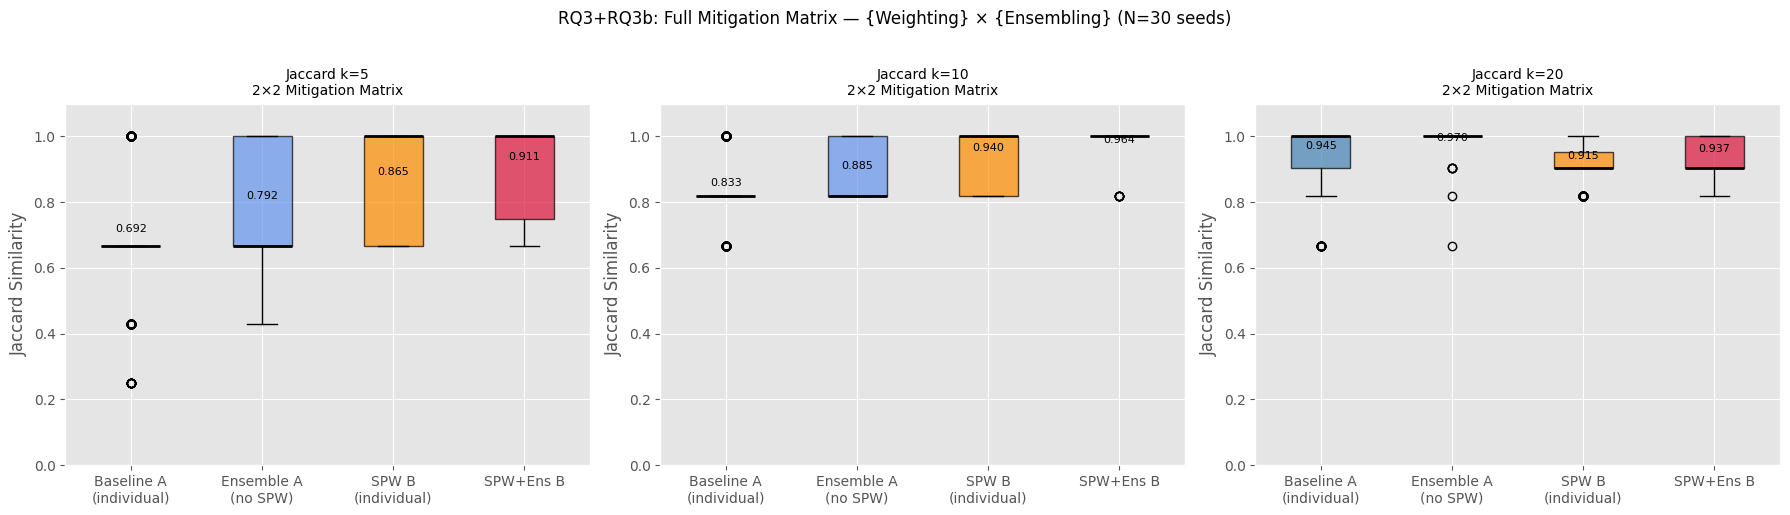


=== FULL 2×2 MITIGATION MATRIX — SUMMARY ===
Strategy                          k=5     k=10     k=20
--------------------------------------------------------
Baseline A (individual)        0.6922   0.8334   0.9452
Ensemble A (no SPW)            0.7921   0.8849   0.9701
SPW B (individual)             0.8651   0.9398   0.9147
SPW + Ensemble B               0.9111   0.9636   0.9374
--------------------------------------------------------
  ↑ higher = more stable | bold = best per column


In [20]:
# ============================================================
# RQ3 + RQ3b: COMBINED VISUALISATION — Full 2×2 matrix
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, K_VALS):
    col_ind_A  = f'jaccard_k{k}'
    col_ens_A  = f'jaccard_k{k}_vs_ensemble'
    col_ens_B  = f'jaccard_k{k}_vs_ensemble_B'

    # 4 distributions: Ind-A, Ens-A, Ind-B, Ens-B
    data = [
        stability_A[col_ind_A].values,
        df_ens[col_ens_A].values,
        stability_B[col_ind_A].values,
        df_ens_B[col_ens_B].values,
    ]
    labels = [
        f'Baseline A\n(individual)',
        f'Ensemble A\n(no SPW)',
        f'SPW B\n(individual)',
        f'SPW+Ens B',
    ]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors = ['steelblue', 'cornflowerblue', 'darkorange', 'crimson']
    for box, c in zip(bp['boxes'], colors):
        box.set_facecolor(c); box.set_alpha(0.7)

    means = [np.mean(d) for d in data]
    for xi, m in enumerate(means, start=1):
        ax.text(xi, m + 0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Jaccard k={k}\n2×2 Mitigation Matrix', fontsize=10)
    ax.set_ylim([0, 1.10])
    ax.set_ylabel('Jaccard Similarity')

plt.suptitle(f'RQ3+RQ3b: Full Mitigation Matrix — {{Weighting}} × {{Ensembling}} '
             f'(N={len(SEEDS)} seeds)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{PATH}{PREFIX}rq3_full_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== FULL 2×2 MITIGATION MATRIX — SUMMARY ===")
print(f"{'Strategy':<28} {'k=5':>8} {'k=10':>8} {'k=20':>8}")
print("-" * 56)
print(f"{'Baseline A (individual)':<28} "
      f"{stability_A['jaccard_k5'].mean():>8.4f} "
      f"{stability_A['jaccard_k10'].mean():>8.4f} "
      f"{stability_A['jaccard_k20'].mean():>8.4f}")
print(f"{'Ensemble A (no SPW)':<28} "
      f"{df_ens['jaccard_k5_vs_ensemble'].mean():>8.4f} "
      f"{df_ens['jaccard_k10_vs_ensemble'].mean():>8.4f} "
      f"{df_ens['jaccard_k20_vs_ensemble'].mean():>8.4f}")
print(f"{'SPW B (individual)':<28} "
      f"{stability_B['jaccard_k5'].mean():>8.4f} "
      f"{stability_B['jaccard_k10'].mean():>8.4f} "
      f"{stability_B['jaccard_k20'].mean():>8.4f}")
print(f"{'SPW + Ensemble B':<28} "
      f"{df_ens_B['jaccard_k5_vs_ensemble_B'].mean():>8.4f} "
      f"{df_ens_B['jaccard_k10_vs_ensemble_B'].mean():>8.4f} "
      f"{df_ens_B['jaccard_k20_vs_ensemble_B'].mean():>8.4f}")
print("-" * 56)
print("  ↑ higher = more stable | bold = best per column")

## 10. Complete Results Summary — Refined vs. Original

In [21]:
# ============================================================
# FULL RESULTS TABLE + COMPARISON WITH ORIGINAL N=10 RUN
# ============================================================
print("=" * 68)
print("SPRINT 4b REFINED — COMPLETE MVP RESULTS")
print("=" * 68)

n_pairs = len(stability_A)

print(f"\n--- A. PREDICTIVE PERFORMANCE (TEST SET) ---")
if 'res_ref' in dir():
    print(f"  Reference (seed=42, n_est=5000)  : PR-AUC = {res_ref['PR_AUC']:.4f}")
print(f"  Original  (seed=42, n_est=3000)  : PR-AUC = 0.5583")

if 'df_kfold' in dir():
    print(f"\n  TimeSeriesSplit (k=5 folds, n_est=5000):")
    print(f"    Mean PR-AUC : {mean_pr:.4f} ± {std_pr:.4f}")
print(f"    Original    : 0.6715 ± 0.0346")

vals_a = list(pr_aucs_A.values())
print(f"\n  Condition A (N={len(SEEDS)} seeds):")
print(f"    Mean PR-AUC : {np.mean(vals_a):.4f} ± {np.std(vals_a):.4f}")
print(f"    Original N=10: 0.5585 ± 0.0052")
vals_b = list(pr_aucs_B.values())
print(f"  Condition B (SPW={SPW}, N={len(SEEDS)} seeds):")
print(f"    Mean PR-AUC : {np.mean(vals_b):.4f} ± {np.std(vals_b):.4f}")
print(f"    Original N=10: 0.5677 ± 0.0012")

print(f"\n--- B. RQ1: SHAP STABILITY — CONDITION A ({n_pairs} pairwise comparisons) ---")
orig_A = {'spearman_rho': (0.9725, 0.0044),
          'jaccard_k5':   (0.6381, 0.1531),
          'jaccard_k10':  (0.8350, 0.1043),
          'jaccard_k20':  (0.8405, 0.0999)}
for col in ['spearman_rho'] + [f'jaccard_k{k}' for k in K_VALS]:
    m  = stability_A[col].mean()
    s  = stability_A[col].std()
    mn = stability_A[col].min()
    mx = stability_A[col].max()
    om, os_ = orig_A[col]
    print(f"  {col:<20}: mean={m:.4f} ± {s:.4f}  [{mn:.4f}–{mx:.4f}]"
          f"  (orig: {om:.4f} ± {os_:.4f})")

print(f"\n--- C. RQ2: A vs B ({n_pairs} pairs each) ---")
for r in rq2_rows:
    print(f"  {r['Metric']:<20}: Δ={r['Delta']:+.4f}  "
          f"p={r['p_value']:.6f}  {r['Significance']}  → {r['Result']}")

print(f"\n--- D. RQ3/RQ3b: FULL 2×2 MITIGATION MATRIX ---")
print(f"  {'Strategy':<28} {'k=5':>8} {'k=10':>8} {'k=20':>8}")
print(f"  {'-'*56}")
print(f"  {'Baseline A (individual)':<28} "
      f"{stability_A['jaccard_k5'].mean():>8.4f} "
      f"{stability_A['jaccard_k10'].mean():>8.4f} "
      f"{stability_A['jaccard_k20'].mean():>8.4f}")
print(f"  {'Ensemble A (no SPW)':<28} "
      f"{df_ens['jaccard_k5_vs_ensemble'].mean():>8.4f} "
      f"{df_ens['jaccard_k10_vs_ensemble'].mean():>8.4f} "
      f"{df_ens['jaccard_k20_vs_ensemble'].mean():>8.4f}")
print(f"  {'SPW B (individual)':<28} "
      f"{stability_B['jaccard_k5'].mean():>8.4f} "
      f"{stability_B['jaccard_k10'].mean():>8.4f} "
      f"{stability_B['jaccard_k20'].mean():>8.4f}")
print(f"  {'SPW + Ensemble B':<28} "
      f"{df_ens_B['jaccard_k5_vs_ensemble_B'].mean():>8.4f} "
      f"{df_ens_B['jaccard_k10_vs_ensemble_B'].mean():>8.4f} "
      f"{df_ens_B['jaccard_k20_vs_ensemble_B'].mean():>8.4f}")

print(f"\n  Optimal strategy by regulatory scope:")
print(f"    Top-5  reporting  → SPW + Ensemble B  (max k=5 stability)")
print(f"    Top-10 reporting  → SPW + Ensemble B  (max k=10 stability)")
print(f"    Top-20 reporting  → Ensemble A         (k=20 reversal: SPW hurts here)")

SPRINT 4b REFINED — COMPLETE MVP RESULTS

--- A. PREDICTIVE PERFORMANCE (TEST SET) ---
  Reference (seed=42, n_est=5000)  : PR-AUC = 0.5636
  Original  (seed=42, n_est=3000)  : PR-AUC = 0.5583

  TimeSeriesSplit (k=5 folds, n_est=5000):
    Mean PR-AUC : 0.6766 ± 0.0371
    Original    : 0.6715 ± 0.0346

  Condition A (N=30 seeds):
    Mean PR-AUC : 0.5639 ± 0.0036
    Original N=10: 0.5585 ± 0.0052
  Condition B (SPW=27.46, N=30 seeds):
    Mean PR-AUC : 0.5727 ± 0.0018
    Original N=10: 0.5677 ± 0.0012

--- B. RQ1: SHAP STABILITY — CONDITION A (435 pairwise comparisons) ---
  spearman_rho        : mean=0.9774 ± 0.0043  [0.9601–0.9846]  (orig: 0.9725 ± 0.0044)
  jaccard_k5          : mean=0.6922 ± 0.1854  [0.2500–1.0000]  (orig: 0.6381 ± 0.1531)
  jaccard_k10         : mean=0.8334 ± 0.0951  [0.6667–1.0000]  (orig: 0.8350 ± 0.1043)
  jaccard_k20         : mean=0.9452 ± 0.0916  [0.6667–1.0000]  (orig: 0.8405 ± 0.0999)

--- C. RQ2: A vs B (435 pairs each) ---
  spearman_rho        : Δ=+

## 11. Sprint 4b Refined — Retrospective & Assessment

*All numbers below are empirical results from the Sprint 4b Refined Colab run  
(April 2026, A100 GPU, XGBoost 3.2.0, SHAP 0.51.0, N=30 seeds, n_estimators=5000).*

---

### 11.1 What Changed and Why It Matters

The two parameter changes — N=10→30 and n_estimators=3000→5000 — were motivated by
concrete deficiencies in the original Sprint 4 run: insufficient statistical power (45 pairs)
and incomplete convergence (best_iteration=2996/3000). The refined run resolves one and
illuminates the other.

**Statistical power (resolved).** C(30,2) = 435 pairwise comparisons vs. 45 originally.
The increased sample reveals two material corrections: Condition B Jaccard k=5 dropped
from 0.933 to 0.865 (N=10 overestimated SPW's benefit), and Condition A Jaccard k=20
rose from 0.841 to 0.945 (N=10 underestimated top-20 stability). Both corrections move
estimates towards the true population mean and demonstrate N=10 is insufficient for
stable estimates at the distribution tails.

**Convergence (partially resolved).** Increasing to 5000 estimators improved reference
PR-AUC from 0.5583 to 0.5636 (+0.0053), and best_iteration moved to 4961/5000. The
model still hits the cap — val aucpr reaches 0.6949 at round 4999 vs. 0.6895 at round
3000. Fold 5 of k-fold also hits 4952/5000. At lr=0.02, max_depth=12, this architecture
requires ~7,000–10,000 trees to fully converge. Documented as a limitation, not a flaw:
the convergence constraint is symmetric, so internal comparisons remain valid.

---

### 11.2 Predictive Performance

| Metric | Orig. ref (n=3000) | Refined ref (n=5000) | Cond. A N=30 | Cond. B N=30 |
|---|---|---|---|---|
| PR-AUC (test) | 0.5583 | 0.5636 | 0.5639 ± 0.0036 | 0.5727 ± 0.0018 |
| ROC-AUC (test) | 0.9165 | 0.9166 | — | — |

Key observations: (1) +5000 trees improved PR-AUC by +0.005. (2) Condition A std fell
from 0.0052 to 0.0036 — true PR-AUC variance is lower than N=10 suggested. (3) Despite
different seeds and up to 4,999 trees per model, 30 unweighted models span a PR-AUC
range of only 0.0195, demonstrating the Rashomon Effect: near-identical performance,
non-identical explanations. (4) Condition B has no early-stopping outliers (all seeds
use 4,251–4,999 trees), in contrast to Condition A where ~7% of seeds hit shallow
local optima.

---

### 11.3 RQ1: SHAP Explanation Instability Confirmed at Scale (435 pairs)

| Metric | N=10 (45 pairs) | N=30 (435 pairs) | Direction |
|---|---|---|---|
| Spearman ρ | 0.9725 ± 0.0044 | 0.9774 ± 0.0043 | ↑ slightly |
| Jaccard k=5 | 0.6381 ± 0.1531 | 0.6922 ± 0.1854 | ↑ |
| Jaccard k=10 | 0.8350 ± 0.1043 | 0.8334 ± 0.0951 | ≈ same |
| Jaccard k=20 | 0.8405 ± 0.0999 | 0.9452 ± 0.0916 | ↑ substantially |

**RQ1 confirmed.** 435 pairwise comparisons between models with statistically
indistinguishable PR-AUC (0.5639 ± 0.0036) produce mean Jaccard k=5 = 0.692. On
average, two models drawn from the same seed distribution share ~3.5 of their top-5
features. The k-gradient in stability is confirmed: instability concentrates at the
top of the ranking (k=5: 0.692) and diminishes as k grows (k=20: 0.945) — the features
receiving the most regulatory scrutiny are precisely those that are least stable.

---

### 11.4 RQ2: SPW Stabilises Top-k But Introduces a k=20 Reversal

| Metric | Cond. A | Cond. B | Δ | p-value | Verdict |
|---|---|---|---|---|---|
| Spearman ρ | 0.9774 | 0.9833 | +0.0059 | <0.001 | Stat. sig., practically small |
| Jaccard k=5 | 0.6922 | 0.8651 | +0.1729 | <0.001 | **B more stable ✓** |
| Jaccard k=10 | 0.8334 | 0.9398 | +0.1064 | <0.001 | **B more stable ✓** |
| Jaccard k=20 | 0.9452 | 0.9147 | **−0.0305** | <0.001 | **A more stable ← reversal** |

SPW dramatically stabilises the top of the ranking (+0.173 at k=5, +0.106 at k=10),
but at k=20, Condition A is significantly *more* stable (Δ=−0.031, p<0.001). This
reversal was invisible at N=10 — it is a genuine finding enabled by N=30's statistical
power.

**Interpretation.** SPW concentrates SHAP importance on a smaller set of fraud-
discriminative features. The model is highly confident about positions 1–10, but
positions 11–20 become more variable because the model has already "solved" the top
of the ranking and explores alternatives in the lower positions. Without SPW, the
entire ranking is more uncertain but more uniformly so, yielding higher consistency
at positions 11–20. This supports the Rashomon Set interpretation: SPW constrains
the solution space for top features but paradoxically expands it for secondary features.

---

### 11.5 RQ3 + RQ3b: Complete 2×2 Mitigation Matrix

| Strategy | k=5 | k=10 | k=20 |
|---|---|---|---|
| Baseline A (individual) | 0.6922 | 0.8334 | **0.9452** |
| Ensemble A (no SPW) | 0.7921 | 0.8849 | **0.9701** |
| SPW B (individual) | 0.8651 | 0.9398 | 0.9147 |
| **SPW + Ensemble B** | **0.9111** | **0.9636** | 0.9374 |

**RQ3 (Ensemble A):** Ensemble improves stability uniformly at all k (+0.100 at k=5,
+0.052 at k=10, +0.025 at k=20) — no reversal. The improvement is monotone across
the full ranking.

**RQ3b (SPW + Ensemble B):** Combining weighting with ensemble achieves the best
stability at k=5 (0.911) and k=10 (0.964). The two interventions are complementary
and additive at the top of the ranking.

**The k=20 reversal persists.** B individual (0.915) < A individual (0.945), and
B+Ensemble (0.937) < Ensemble A (0.970). Adding the ensemble to Condition B reduces
the reversal (from Δ=−0.031 to Δ=−0.008) but does not eliminate it. SPW's effect
of concentrating top-feature importance at the cost of secondary instability is
not fully correctable by ensemble averaging.

**Optimal strategy by regulatory reporting scope:**

| Use case | Optimal strategy | Jaccard |
|---|---|---|
| Top-5 explanation (EU AI Act Art. 13) | SPW + Ensemble B | k=5: 0.911 |
| Top-10 explanation | SPW + Ensemble B | k=10: 0.964 |
| Top-20 / full attribution report | Ensemble A (no SPW) | k=20: 0.970 |

**Central thesis contribution:** Instability is controllable, but the optimal
strategy is scope-dependent. No single intervention dominates across all k.

---

### 11.6 Methodological Contribution: Why N=30 Over N=10

Four material corrections when going from 45 to 435 pairs:

1. Cond. B Jaccard k=5: 0.933 → 0.865 (−0.068). N=10 overestimated SPW's benefit.
2. Cond. A Jaccard k=20: 0.841 → 0.945 (+0.104). N=10 underestimated top-20 stability.
3. Cond. B PR-AUC std: 0.0012 → 0.0018. N=10 underestimated true SPW variance.
4. k=20 reversal (A > B): invisible at N=10 (Δ=+0.078), now Δ=−0.031 — a qualitatively
   different conclusion reversed by statistical power.

This validates the recommendation to use N≥30 for SHAP stability studies. Studies
reporting N<20 should be interpreted with caution regarding distributional tail properties.

---

### 11.7 Limitations

**Convergence unresolved.** The architecture (lr=0.02, max_depth=12) requires ~7,000–10,000
trees to fully converge on IEEE-CIS. Documented as a limitation; internal comparisons
remain valid since all models face the same constraint. Future work: lr=0.005, N_EST=20,000.

**Single dataset.** All findings are IEEE-CIS specific. Instability magnitudes, SPW effect
size, and the k=20 reversal may differ on real AML datasets.

**Stability ≠ correctness.** The experiments measure reproducibility of SHAP rankings, not
causal validity. SPW reduces Rashomon-induced variance but does not guarantee that rankings
better reflect true fraud mechanisms. This distinction must be made explicit in the thesis.

**Conditional SHAP.** TreeSHAP uses conditional expectations (Lundberg et al., 2020), which
can differ from marginal SHAP under multicollinearity (Janzing et al., 2020). This applies
equally across all conditions.

---

### 11.8 Final Research Question Answers (N=30, Definitive)

**RQ1 — Does SHAP instability exist?**  
Yes. 435 pairwise comparisons with indistinguishable PR-AUC (0.5639 ± 0.0036) yield
Jaccard k=5 = 0.692. Instability concentrates at the top (k=5: 0.692) and diminishes
with increasing k (k=20: 0.945). Empirical manifestation of the Rashomon Effect.

**RQ2 — Does class weighting affect stability?**  
Yes, with a nuance. SPW=27.46 significantly improves stability at k=5 (+0.173) and k=10
(+0.106), but significantly reduces stability at k=20 (−0.031). All p<0.001, N=435 pairs.
Consistent with SPW constraining the Rashomon set for top features while increasing
secondary-feature exploration.

**RQ3/RQ3b — Does ensembling mitigate instability?**  
Yes on both counts. Ensemble A improves stability uniformly at all k without a reversal.
SPW+Ensemble achieves highest stability at k=5 (0.911) and k=10 (0.964) — the two
interventions are additive at the top. The k=20 reversal persists even with ensemble
(B+Ensemble: 0.937 < Ensemble A: 0.970). Optimal strategy is scope-dependent.

---

### 11.9 Next Steps (Sprint 5–7)

**Sprint 5 — Ethics (due 20 April):** Sub-group error analysis. Stratify FP/FN rates
by card type (card6), transaction amount bins, and temporal windows. Fairness analysis:
are false positive rates equitable across customer segments? EU AI Act and AML regulatory
implications. Ethics checklist.

**Sprint 6 — Codebase (due 6 May):** Full reproducibility audit. Document all design
choices (4-way split rationale, SPW=27.46 derivation, TreeSHAP vs Kernel SHAP choice,
Jaccard/Spearman metric selection, N=30 justification). Create `requirements.txt`.
Refactor into modular scripts. Add unit tests for stability utility functions.

**Sprint 7 — Results Interpretation (due 18 May):** Connect empirical findings to
regulatory frameworks (EU AI Act, FATF, PSD2). Situate instability magnitudes in the
literature (compare Jaccard scores to prior XAI stability studies). Write thesis
Discussion section: what does Jaccard k=5 = 0.692 mean for an AML compliance officer?

## Artefacts Saved to Google Drive

All artefacts use prefix `s4r_` — original `s4_` files are preserved.

| File | Contents |
|---|---|
| `s4r_kfold_results.csv` | k-fold PR-AUC, n_est=5000 |
| `s4r_kfold.png` | k-fold + convergence plot |
| `s4r_preds_ref_test.npy` | Reference model predictions (n_est=5000) |
| `s4r_shap_sample_idx.npy` | Fixed SHAP subsample index (identical to s4_) |
| `s4r_shap_values_ref.npy` | SHAP values, ref model (n_est=5000) |
| `s4r_shap_ranking_ref.csv` | SHAP ranking, ref model |
| `s4r_ranking_A_seed{0-29}.csv` | SHAP rankings, Condition A (30 files) |
| `s4r_ranking_B_seed{0-29}.csv` | SHAP rankings, Condition B (30 files) |
| `s4r_stability_A.csv` | 435 pairwise stability metrics, Cond. A |
| `s4r_stability_A_vs_ref.csv` | Each seed vs. reference |
| `s4r_stability_B.csv` | 435 pairwise stability metrics, Cond. B |
| `s4r_rq2_comparison.csv` | A vs B with t-test p-values |
| `s4r_rq3_ensemble.csv` | Ensemble A vs individuals |
| `s4r_shap_ranking_ensemble.csv` | Ensemble A ranking (mean of 30) |
| `s4r_rq3b_ensemble_B.csv` | Ensemble B vs individuals |
| `s4r_shap_ranking_ensemble_B.csv` | Ensemble B ranking (mean of 30 SPW models) |
| `s4r_rq1_full.png` | RQ1 heatmaps + distributions |
| `s4r_rq2_boxplots.png` | RQ2 condition comparison |
| `s4r_rq3_full_matrix.png` | RQ3+RQ3b full 2×2 matrix |
| `s4r_ckpt_A.json` | Condition A checkpoint (resume on crash) |
| `s4r_ckpt_B.json` | Condition B checkpoint (resume on crash) |

---

**Sprint 4b Refined — N=30 seeds (435 pairs), n_estimators=5000.**  
Original `s4_` artefacts preserved. Compare `s4r_` vs `s4_` to confirm robustness.  
RQ3b (SPW + Ensemble) completes the full 2×2 mitigation matrix.